# Synthetic Image Generation with Federated Learning for Cancer Classification


```
PHASE 1 — Environment Setup
PHASE 2 — Federated Diffusion Model Training  
PHASE 3 — Synthetic Image Generation         
PHASE 4 — Federated Classifier Training       
PHASE 5 — Evaluation & FID
```

## PHASE 1 — Environment Setup

In [ ]:
!pip install -q torch torchvision tqdm scikit-learn matplotlib scipy diffusers accelerate

In [ ]:
import os
import copy
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset, ConcatDataset, random_split
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights, Inception_V3_Weights
from torchvision.utils import save_image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[INFO] Device: cuda


In [ ]:
# ── Google Drive Mount ────────────────────────────────────────────
# Run once per session. Checkpoints survive runtime resets.
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/federated_project'
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
print(f"Drive mounted. Saving checkpoints to: {DRIVE_PROJECT_DIR}")

Mounted at /content/drive
✅ Drive mounted. Saving checkpoints to: /content/drive/MyDrive/federated_project


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Paths ────────────────────────────────────────────────────────
BASE_DATA_DIR       = './isic_data'
SYNTHETIC_PATH      = './synthetic_data'
DIFF_SAVE_DIR       = '/content/drive/MyDrive/federated_project/diffusion_checkpoints'
CLF_SAVE_DIR        = '/content/drive/MyDrive/federated_project/classifier_checkpoints'

os.makedirs(SYNTHETIC_PATH, exist_ok=True)
os.makedirs(DIFF_SAVE_DIR,  exist_ok=True)
os.makedirs(CLF_SAVE_DIR,   exist_ok=True)

# ── Shared federated settings ─────────────────────────────────────
NUM_CLIENTS         = 2
IID_SPLIT           = False

# ── Diffusion model settings ─────────
DIFF_IMAGE_SIZE     = 64
DIFF_BATCH_SIZE     = 32
DIFF_LR             = 2e-4
DIFF_NUM_TIMESTEPS  = 1000
DDIM_STEPS          = 50
DIFF_NUM_ROUNDS     = 10
DIFF_LOCAL_EPOCHS   = 10
DIFF_BLOCK_CHANNELS = (64, 128, 256)
SYNTH_PER_CLASS     = 1500
CLASS_NAMES         = ['benign', 'malignant']

# ── Classifier settings ───────────────
CLF_IMAGE_SIZE      = 224
CLF_BATCH_SIZE      = 32
CLF_NUM_ROUNDS      = 10
CLF_LOCAL_EPOCHS    = 5
CLF_LR              = 1e-4
CLF_TEST_SPLIT      = 0.2
SYNTHETIC_AUGMENT   = True

print("[CONFIG] All paths and hyperparameters loaded.")
print(f"  Diffusion image size : {DIFF_IMAGE_SIZE}×{DIFF_IMAGE_SIZE}")
print(f"  Classifier image size: {CLF_IMAGE_SIZE}×{CLF_IMAGE_SIZE}")

[CONFIG] All paths and hyperparameters loaded.
  Diffusion image size : 64×64
  Classifier image size: 224×224


---
## PHASE 2 — Data Download & Federated Diffusion Model Training


In [ ]:
# ── Data Download & Sorting (ISIC HAM10000) ───────────────────────
MALIGNANT_DIR = os.path.join(BASE_DATA_DIR, 'malignant')
BENIGN_DIR    = os.path.join(BASE_DATA_DIR, 'benign')
CSV_FILE      = 'HAM10000_metadata.csv'
TASK3_ZIP     = 'ISIC2018_Task3_Training_Input.zip'
IMAGES_SRC    = os.path.join(BASE_DATA_DIR, 'ISIC2018_Task3_Training_Input')

is_prepared = (
    os.path.exists(MALIGNANT_DIR) and len(os.listdir(MALIGNANT_DIR)) > 0 and
    os.path.exists(BENIGN_DIR)    and len(os.listdir(BENIGN_DIR))    > 0
)

if is_prepared:
    print(f"Dataset already prepared.")
    print(f"   Malignant: {len(os.listdir(MALIGNANT_DIR))} | Benign: {len(os.listdir(BENIGN_DIR))}")
else:
    print("Downloading and structuring dataset...")
    if os.path.exists(BASE_DATA_DIR): shutil.rmtree(BASE_DATA_DIR)
    os.makedirs(MALIGNANT_DIR, exist_ok=True)
    os.makedirs(BENIGN_DIR,    exist_ok=True)

    !wget -q --show-progress -O {TASK3_ZIP} "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_Input.zip"
    !unzip -q {TASK3_ZIP} -d {BASE_DATA_DIR}
    os.remove(TASK3_ZIP)

    !wget -q -O {CSV_FILE} "https://dataverse.harvard.edu/api/access/datafile/3172582?format=original"
    df = pd.read_csv(CSV_FILE)

    malignant_classes = ['mel', 'bcc', 'akiec']
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Sorting images"):
        src = os.path.join(IMAGES_SRC, f"{row['image_id']}.jpg")
        if os.path.exists(src):
            dst = MALIGNANT_DIR if row['dx'] in malignant_classes else BENIGN_DIR
            shutil.move(src, os.path.join(dst, f"{row['image_id']}.jpg"))

    if os.path.exists(IMAGES_SRC): shutil.rmtree(IMAGES_SRC)
    if os.path.exists(CSV_FILE):   os.remove(CSV_FILE)
    print(f"\n Done. Malignant: {len(os.listdir(MALIGNANT_DIR))} | Benign: {len(os.listdir(BENIGN_DIR))}")

🚀 Downloading and structuring dataset...
ISIC2018_Task3_Trai 100%[===================>]   2.58G  5.78MB/s    in 6m 11s  


Sorting images: 100%|██████████| 10015/10015 [00:01<00:00, 7781.24it/s]

✅ Done. Malignant: 1954 | Benign: 8061


In [ ]:
# ── Diffusion Data Loading (64×64, both classes) ─────────────────
#
# We load BOTH classes here (not just malignant) so the diffusion
# model can generate both.  At generation time we specify which
# class label to produce.
#

diff_transform = transforms.Compose([
    transforms.Resize((DIFF_IMAGE_SIZE, DIFF_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # → [-1, 1]
])

diff_full_dataset = datasets.ImageFolder(root=BASE_DATA_DIR, transform=diff_transform)

# Remove any ghost folder that ImageFolder would count as a class
ghost = os.path.join(BASE_DATA_DIR, 'ISIC2018_Task3_Training_Input')
if os.path.isdir(ghost): shutil.rmtree(ghost)

print(f"[DIFF DATA] Total images : {len(diff_full_dataset)}")
print(f"[DIFF DATA] Classes      : {diff_full_dataset.class_to_idx}")

# ── IID / Non-IID split for diffusion clients ─────────────────────
def partition_iid(dataset, num_clients):
    indices = torch.randperm(len(dataset)).tolist()
    s = len(indices) // num_clients
    return [indices[i*s:(i+1)*s if i < num_clients-1 else len(indices)]
            for i in range(num_clients)]

def partition_non_iid_by_class(dataset, num_clients):
    """Each client receives a disjoint subset of classes (exactly as in the report)."""
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices.setdefault(label, []).append(idx)
    all_classes = sorted(class_indices.keys())
    partitions  = [[] for _ in range(num_clients)]
    for i, cls in enumerate(all_classes):
        partitions[i % num_clients].extend(class_indices[cls])
    for i, p in enumerate(partitions):
        print(f"   Non-IID Diff Client {i}: {len(p)} samples, classes "
              f"{set(dataset.targets[j] for j in p)}")
    return partitions

if IID_SPLIT:
    diff_client_idx = partition_iid(diff_full_dataset, NUM_CLIENTS)
else:
    diff_client_idx = partition_non_iid_by_class(diff_full_dataset, NUM_CLIENTS)

diff_client_loaders = []
for i, idx_list in enumerate(diff_client_idx):
    loader = DataLoader(
        Subset(diff_full_dataset, idx_list),
        batch_size=DIFF_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False,   # pin_memory only helps when num_workers > 0
    )
    diff_client_loaders.append(loader)
    print(f"[DIFF DATA] Client {i}: {len(idx_list)} images")

[DIFF DATA] Total images : 10015
[DIFF DATA] Classes      : {'benign': 0, 'malignant': 1}
[DIFF DATA] Client 0: 5007 images
[DIFF DATA] Client 1: 5008 images


In [ ]:
# ── Pre-cache diffusion dataset to RAM ───────────────────────────
# Loads all images resized to 64×64 into RAM once.
# Eliminates per-batch disk IO and resize overhead on every epoch.
#
# Safe for diffusion only — diff_transform has no random augmentations,
# so cached tensors are identical to fresh loads every time.
# Do NOT cache the classifier dataset (it uses random flips/rotations).


from torch.utils.data import TensorDataset

print("Pre-caching diffusion dataset to RAM...")
tmp_loader = DataLoader(diff_full_dataset, batch_size=128,
                        shuffle=False, num_workers=0)
all_imgs, all_lbls = [], []
for imgs, lbls in tqdm(tmp_loader, desc="Caching"):
    all_imgs.append(imgs)
    all_lbls.append(lbls)

cached_imgs    = torch.cat(all_imgs)
cached_lbls    = torch.cat(all_lbls)
cached_dataset = TensorDataset(cached_imgs, cached_lbls)
print(f"✅ Cached {len(cached_dataset)} images  |  shape: {cached_imgs.shape}")

# Rebuild the client loaders from the cached dataset
diff_client_loaders = []
for i, idx_list in enumerate(diff_client_idx):
    loader = DataLoader(
        Subset(cached_dataset, idx_list),
        batch_size=DIFF_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )
    diff_client_loaders.append(loader)
    print(f"[DIFF CACHE] Client {i}: {len(idx_list)} images")

Pre-caching diffusion dataset to RAM...


Caching:   3%|▎         | 2/79 [00:03<02:18,  1.80s/it]


KeyboardInterrupt: 

In [ ]:
# ── Diffusion Model Definition ────────────────────────────────────

def build_diff_model():
    """Returns a fresh UNet2DModel ready for diffusion training."""
    return UNet2DModel(
        sample_size       = DIFF_IMAGE_SIZE,
        in_channels       = 3,
        out_channels      = 3,
        layers_per_block  = 2,
        block_out_channels= DIFF_BLOCK_CHANNELS,      # (128, 256, 256, 512)
        down_block_types  = ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
        up_block_types    = ("UpBlock2D",   "UpBlock2D",   "AttnUpBlock2D",   "UpBlock2D"),
    ).to(device)

global_diff_model   = build_diff_model()
train_scheduler     = DDPMScheduler(num_train_timesteps=DIFF_NUM_TIMESTEPS)
inference_scheduler = DDIMScheduler.from_config(train_scheduler.config)

param_count = sum(p.numel() for p in global_diff_model.parameters())
print(f"[DIFF MODEL] UNet2DModel built — {param_count/1e6:.1f}M parameters")
print(f"[DIFF MODEL] sample_size = {DIFF_IMAGE_SIZE}  (not {CLF_IMAGE_SIZE} — these MUST differ)")

[DIFF MODEL] UNet2DModel built — 17.2M parameters
[DIFF MODEL] sample_size = 64  (not 224 — these MUST differ)


In [ ]:
# ── Federated Diffusion Training Loop ────────────────────────────

def diff_client_train(client_id, model_state, dataloader, round_num):
    local_model = build_diff_model()
    local_model.load_state_dict(copy.deepcopy(model_state))
    local_model.train()
    optimizer = Adam(local_model.parameters(), lr=DIFF_LR)

    epoch_losses = []
    pbar = tqdm(range(DIFF_LOCAL_EPOCHS),
                desc=f"  [Client {client_id}] Round {round_num}", leave=False)

    for epoch in pbar:
        running_loss, steps = 0.0, 0
        for batch_images, _ in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()

            noise     = torch.randn_like(batch_images)
            timesteps = torch.randint(0, DIFF_NUM_TIMESTEPS,
                                      (batch_images.shape[0],), device=device).long()
            noisy     = train_scheduler.add_noise(batch_images, noise, timesteps)
            pred      = local_model(noisy, timesteps).sample
            loss      = F.mse_loss(pred, noise)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            steps += 1

        ep_loss = running_loss / max(steps, 1)
        epoch_losses.append(ep_loss)
        pbar.set_postfix({'loss': f'{ep_loss:.4f}'})

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"  ✓ [Client {client_id}] Avg MSE Loss: {avg_loss:.4f}")
    return local_model.state_dict(), len(dataloader.dataset)


def fedavg_diff(global_state, client_updates):
    total = sum(n for _, n in client_updates)
    agg   = copy.deepcopy(global_state)
    for key in agg:
        agg[key] = torch.zeros_like(agg[key], dtype=torch.float32)
        for state, n in client_updates:
            agg[key] += state[key].float() * (n / total)
    return agg


print("=" * 60)
print(f"  FEDERATED DIFFUSION TRAINING — {DIFF_NUM_ROUNDS} ROUNDS")
print("=" * 60)

global_diff_state = global_diff_model.state_dict()
start_time = time.time()

for r in range(1, DIFF_NUM_ROUNDS + 1):
    print(f"\n ROUND {r}/{DIFF_NUM_ROUNDS}")
    client_updates = []
    for c in range(NUM_CLIENTS):
        state, n = diff_client_train(c, global_diff_state, diff_client_loaders[c], r)
        client_updates.append((state, n))
    global_diff_state = fedavg_diff(global_diff_state, client_updates)
    print(f"  ← FedAvg aggregation complete (round {r})")

    # checkpoint every 5 rounds
    if r % 5 == 0 or r == DIFF_NUM_ROUNDS:
        global_diff_model.load_state_dict(global_diff_state)
        ckpt = os.path.join(DIFF_SAVE_DIR, f'round_{r:03d}')
        global_diff_model.save_pretrained(ckpt)
        print(f"Checkpoint saved → {ckpt}")

# load final weights and immediately set eval + rebuild scheduler
global_diff_model.load_state_dict(global_diff_state)
global_diff_model.eval()

# rebuild scheduler fresh in the same session
train_scheduler     = DDPMScheduler(num_train_timesteps=DIFF_NUM_TIMESTEPS)
inference_scheduler = DDIMScheduler.from_config(train_scheduler.config)
inference_scheduler.set_timesteps(DDIM_STEPS, device=device)
print(f"  Scheduler ready: {len(inference_scheduler.timesteps)} DDIM steps")
print(f"\n Diffusion training complete in {(time.time()-start_time)/60:.1f} min")

  FEDERATED DIFFUSION TRAINING — 10 ROUNDS

🌐 ROUND 1/10


  ✓ [Client 0] Avg MSE Loss: 0.0220


  ✓ [Client 1] Avg MSE Loss: 0.0218
  ← FedAvg aggregation complete (round 1)

🌐 ROUND 2/10


  ✓ [Client 0] Avg MSE Loss: 0.0115


  ✓ [Client 1] Avg MSE Loss: 0.0113
  ← FedAvg aggregation complete (round 2)

🌐 ROUND 3/10


...

  ✓ [Client 1] Avg MSE Loss: 0.0097
  ← FedAvg aggregation complete (round 8)

🌐 ROUND 9/10


  ✓ [Client 0] Avg MSE Loss: 0.0096


  ✓ [Client 1] Avg MSE Loss: 0.0100
  ← FedAvg aggregation complete (round 9)

🌐 ROUND 10/10


  ✓ [Client 0] Avg MSE Loss: 0.0094


  ✓ [Client 1] Avg MSE Loss: 0.0096
  ← FedAvg aggregation complete (round 10)
  💾 Checkpoint saved → /content/drive/MyDrive/federated_project/diffusion_checkpoints/round_010
  Scheduler ready: 50 DDIM steps

✅ Diffusion training complete in 400.5 min
⚡ Run Phase 3 generation NOW — do not restart the runtime.


---
## PHASE 3 — Synthetic Image Generation

We generate synthetic images for both classes using DDIM fast sampling
.  
The images are saved to `./synthetic_data/{class_name}/` so the classifier can  
optionally load them as augmentation data in Phase 4.

In [ ]:
# ── LOAD CHECKPOINT ─────────


BEST_CHECKPOINT = os.path.join(DIFF_SAVE_DIR, f'round_{DIFF_NUM_ROUNDS:03d}')
FALLBACK_CKPT   = os.path.join(DIFF_SAVE_DIR, 'interrupted_round')

def load_diff_checkpoint(primary, fallback):
    for path in [primary, fallback]:
        if os.path.exists(path):
            model = UNet2DModel.from_pretrained(path).to(device)
            print(f"Loaded diffusion checkpoint from: {path}")
            assert model.config.sample_size == DIFF_IMAGE_SIZE, (
                f"Checkpoint sample_size={model.config.sample_size} "
                f"but DIFF_IMAGE_SIZE={DIFF_IMAGE_SIZE}. "
                "Delete old checkpoints and retrain."
            )
            return model
    print("No checkpoint found - using model from current RAM session.")
    print("If you just finished training, this is fine.")
    print("If runtime was reset, re-run Phase 2 first.")
    return global_diff_model

# Only reload from disk if the in-memory model hasn't been trained!!
try:
    _ = global_diff_state
    print("Using trained diffusion model from current session.")
except NameError:
    global_diff_model = load_diff_checkpoint(BEST_CHECKPOINT, FALLBACK_CKPT)

global_diff_model.eval()

# Always rebuild scheduler fresh when loading from checkpoint
train_scheduler     = DDPMScheduler(num_train_timesteps=DIFF_NUM_TIMESTEPS)
inference_scheduler = DDIMScheduler.from_config(train_scheduler.config)
inference_scheduler.set_timesteps(DDIM_STEPS, device=device)
print(f"[GEN] Diffusion model ready. sample_size={global_diff_model.config.sample_size}")
print(f"[GEN] Scheduler: {len(inference_scheduler.timesteps)} DDIM steps")
print(f"[GEN] Timesteps: {inference_scheduler.timesteps[0].item()} → {inference_scheduler.timesteps[-1].item()}")

✅ Loaded diffusion checkpoint from: /content/drive/MyDrive/federated_project/diffusion_checkpoints/round_010
[GEN] Diffusion model ready. sample_size=64
[GEN] Scheduler: 50 DDIM steps
[GEN] Timesteps: 980 → 0


In [ ]:
# ── DDIM Generation (both classes)


SYN_MALIGNANT_DIR = os.path.join(SYNTHETIC_PATH, 'malignant')
SYN_BENIGN_DIR    = os.path.join(SYNTHETIC_PATH, 'benign')
os.makedirs(SYN_MALIGNANT_DIR, exist_ok=True)
os.makedirs(SYN_BENIGN_DIR,    exist_ok=True)


GEN_BATCH   = 16

def generate_images(n_images, save_dir, prefix, batch_size=GEN_BATCH):
    """Generate n_images via DDIM and save to save_dir."""
    count = 0
    pbar  = tqdm(total=n_images, desc=f"Generating → {os.path.basename(save_dir)}")
    while count < n_images:
        bs     = min(batch_size, n_images - count)
        sample = torch.randn(bs, 3, DIFF_IMAGE_SIZE, DIFF_IMAGE_SIZE, device=device)
        with torch.no_grad():
            for t in inference_scheduler.timesteps:
                residual = global_diff_model(sample, t).sample
                sample   = inference_scheduler.step(residual, t, sample).prev_sample
        sample = ((sample + 1.0) / 2.0).clamp(0, 1)
        for i in range(bs):
            save_image(sample[i], os.path.join(save_dir, f"{prefix}_{count+1:05d}.jpg"))
            count += 1
            pbar.update(1)
    pbar.close()
    return count

print("=" * 60)
print(f"  GENERATING {SYNTH_PER_CLASS} SYNTHETIC MALIGNANT IMAGES")
print("=" * 60)

t0 = time.time()
n  = generate_images(SYNTH_PER_CLASS, SYN_MALIGNANT_DIR, 'syn_mal')
print(f"Generated {n} malignant images in {(time.time()-t0)/60:.1f} min")
print(f"Saved to: {SYN_MALIGNANT_DIR}")

# generate_images(SYNTH_PER_CLASS, SYN_BENIGN_DIR, 'syn_ben')

  GENERATING 1500 SYNTHETIC MALIGNANT IMAGES


Generating → malignant: 100%|██████████| 1500/1500 [08:12<00:00,  3.05it/s]

✅ Generated 1500 malignant images in 8.2 min
   Saved to: ./synthetic_data/malignant


In [ ]:
# ── visul check of gen images ────────────────────────
from torchvision.utils import make_grid
from PIL import Image

syn_files = sorted(os.listdir(SYN_MALIGNANT_DIR))[:16]
imgs = []
for f in syn_files:
    img = Image.open(os.path.join(SYN_MALIGNANT_DIR, f)).convert('RGB')
    imgs.append(transforms.ToTensor()(img))

grid = make_grid(imgs, nrow=4, padding=2)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Sample Synthetic Malignant Images (DDIM, 64×64)', fontsize=13)
plt.tight_layout()
plt.show()

---
## PHASE 4 — Federated Classifier Training


Train with `SYNTHETIC_AUGMENT = False` → baseline accuracy  
Train with `SYNTHETIC_AUGMENT = True`  → augmented accuracy  


In [ ]:
# ── Classifier Data Loading  ────────────────────────────

train_transform = transforms.Compose([
    transforms.Resize((CLF_IMAGE_SIZE, CLF_IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((CLF_IMAGE_SIZE, CLF_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

ghost = os.path.join(BASE_DATA_DIR, 'ISIC2018_Task3_Training_Input')
if os.path.isdir(ghost): shutil.rmtree(ghost)

full_dataset      = datasets.ImageFolder(root=BASE_DATA_DIR, transform=train_transform)
full_dataset_eval = datasets.ImageFolder(root=BASE_DATA_DIR, transform=eval_transform)

print(f"[CLF DATA] Real images: {len(full_dataset)}")
print(f"[CLF DATA] Classes    : {full_dataset.class_to_idx}")

# 1-split real data only
n_real        = len(full_dataset)
n_real_test   = int(n_real * CLF_TEST_SPLIT)
n_real_train  = n_real - n_real_test

real_train_ds, real_test_ds = random_split(
    full_dataset, [n_real_train, n_real_test],
    generator=torch.Generator().manual_seed(42)
)

test_subset = Subset(full_dataset_eval, real_test_ds.indices)
test_loader = DataLoader(test_subset, batch_size=CLF_BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print(f"[CLF DATA] Fixed test set : {len(test_subset)} real images")

# 2- add synthetic to train only (optional)
if SYNTHETIC_AUGMENT and os.path.exists(SYNTHETIC_PATH):
    syn_dataset = datasets.ImageFolder(root=SYNTHETIC_PATH, transform=train_transform,
                                       allow_empty=True)
    assert syn_dataset.class_to_idx == full_dataset.class_to_idx, (
        "Synthetic folder class names don't match real folder class names!\n"
        f"Real: {full_dataset.class_to_idx}  Synthetic: {syn_dataset.class_to_idx}"
    )
    train_ds = ConcatDataset([real_train_ds, syn_dataset])
    print(f"[CLF DATA] Train: {len(real_train_ds)} real + {len(syn_dataset)} synthetic = {len(train_ds)} total")
else:
    train_ds = real_train_ds
    if SYNTHETIC_AUGMENT:
        print("SYNTHETIC_AUGMENT=True but no synthetic images found. Run Phase 3 first.")
    print(f"[CLF DATA] Train: {len(train_ds)} real images (no synthetic)")

[CLF DATA] Real images: 10015
[CLF DATA] Classes    : {'benign': 0, 'malignant': 1}
[CLF DATA] Fixed test set : 2003 real images (seed=42, never changes)
[CLF DATA] Train: 8012 real images (no synthetic)


In [ ]:
# ── Federated partitioning for classifier clients ────────────────

def partition_clf_iid(dataset, num_clients):
    indices = torch.randperm(len(dataset)).tolist()
    s = len(indices) // num_clients
    return [indices[i*s:(i+1)*s if i < num_clients-1 else len(indices)]
            for i in range(num_clients)]

def partition_clf_non_iid(dataset, num_clients):
    """90/10 class-imbalanced split to simulate different hospital distributions."""
    base = dataset.dataset if hasattr(dataset, 'dataset') else dataset
    class_indices = {0: [], 1: []}
    idx_source = dataset.indices if hasattr(dataset, 'indices') else range(len(dataset))
    for idx in idx_source:
        _, label = base[idx]
        class_indices[label].append(idx)
    partitions = [[], []]
    for cls, idxs in class_indices.items():
        np.random.shuffle(idxs)
        split = int(len(idxs) * 0.9)
        partitions[cls].extend(idxs[:split])          # 90% to owner client
        partitions[1 - cls].extend(idxs[split:])      # 10% cross-over
    for i, p in enumerate(partitions):
        print(f"   Non-IID CLF Client {i}: {len(p)} samples")
    return partitions

clf_idx = partition_clf_iid(train_ds, NUM_CLIENTS) if IID_SPLIT else \
          partition_clf_non_iid(train_ds, NUM_CLIENTS)

clf_client_loaders = []
for i, idx_list in enumerate(clf_idx):
    loader = DataLoader(Subset(train_ds, idx_list), batch_size=CLF_BATCH_SIZE,
                        shuffle=True, num_workers=2, pin_memory=True)
    clf_client_loaders.append(loader)
    print(f"[CLF DATA] Client {i}: {len(idx_list)} training images")

[CLF DATA] Client 0: 4006 training images
[CLF DATA] Client 1: 4006 training images


In [ ]:
# ── EfficientNet-B0 Classifier ────────────────────────────────────

def build_classifier():
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 2),     # benign=0, malignant=1
    )
    return model.to(device)

global_clf_model = build_classifier()
print("[CLF MODEL] EfficientNet-B0 loaded — binary classification head attached")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 97.7MB/s]


[CLF MODEL] EfficientNet-B0 loaded — binary classification head attached


In [ ]:
# ── Client Training & FedAvg for Classifier ──────────────────────

def clf_client_train(client_id, model_state, dataloader, local_epochs):
    local_model = build_classifier()
    local_model.load_state_dict(copy.deepcopy(model_state))
    local_model.train()
    optimizer = Adam(local_model.parameters(), lr=CLF_LR)
    criterion = nn.CrossEntropyLoss()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    for epoch in range(local_epochs):
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out   = local_model(images)
            loss  = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_correct += (out.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)
            total_loss    += loss.item()

        acc = total_correct / total_samples
        avg = total_loss / max(len(dataloader) * (epoch + 1), 1)
        print(f"   [Client {client_id}] Epoch {epoch+1} | Loss: {avg:.4f} | Acc: {acc:.4f}")

    return local_model.state_dict(), len(dataloader.dataset)


def fedavg_clf(global_state, client_updates):
    total = sum(n for _, n in client_updates)
    agg   = copy.deepcopy(global_state)
    for key in agg:
        agg[key] = torch.zeros_like(agg[key], dtype=torch.float32)
        for state, n in client_updates:
            agg[key] += state[key].float() * (n / total)
    return agg


def evaluate_clf(model, dataloader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds, all_labels, all_probs = [], [], []
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            out   = model(images)
            loss  = criterion(out, labels)
            probs = F.softmax(out, dim=1)[:, 1]
            preds = out.argmax(1)
            total_loss    += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (total_loss / max(total_samples, 1),
            total_correct / max(total_samples, 1),
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


# ── Main federated loop ───────────────────────────────────────────
print("=" * 60)
print(f"  FEDERATED CLASSIFIER — {CLF_NUM_ROUNDS} ROUNDS")
print(f"  Synthetic augmentation: {SYNTHETIC_AUGMENT}")
print("=" * 60)

round_accs, round_losses = [], []

for r in range(1, CLF_NUM_ROUNDS + 1):
    print(f"\n{'─'*50}\n  ROUND {r}/{CLF_NUM_ROUNDS}\n{'─'*50}")
    client_updates = []
    for c in range(NUM_CLIENTS):
        print(f"\n  → Client {c} training...")
        state, n = clf_client_train(c, global_clf_model.state_dict(),
                                    clf_client_loaders[c], CLF_LOCAL_EPOCHS)
        client_updates.append((state, n))

    agg_state = fedavg_clf(global_clf_model.state_dict(), client_updates)
    global_clf_model.load_state_dict(agg_state)

    loss, acc, _, _, _ = evaluate_clf(global_clf_model, test_loader)
    round_accs.append(acc)
    round_losses.append(loss)
    print(f"  ✓ Round {r} | Test Acc: {acc:.4f} | Loss: {loss:.4f}")

    if r % 5 == 0 or r == CLF_NUM_ROUNDS:
        ckpt = os.path.join(CLF_SAVE_DIR, f'classifier_round_{r:03d}.pt')
        torch.save(global_clf_model.state_dict(), ckpt)
        print(f"!! Checkpoint → {ckpt}")

print("\nFederated classifier training complete!")

  FEDERATED CLASSIFIER — 10 ROUNDS
  Synthetic augmentation: False

──────────────────────────────────────────────────
  ROUND 1/10
──────────────────────────────────────────────────

  → Client 0 training...
   [Client 0] Epoch 1 | Loss: 0.4100 | Acc: 0.8078
   [Client 0] Epoch 2 | Loss: 0.3532 | Acc: 0.8369
   [Client 0] Epoch 3 | Loss: 0.3242 | Acc: 0.8527
   [Client 0] Epoch 4 | Loss: 0.3001 | Acc: 0.8650
   [Client 0] Epoch 5 | Loss: 0.2810 | Acc: 0.8746

  → Client 1 training...
   [Client 1] Epoch 1 | Loss: 0.4158 | Acc: 0.8018
   [Client 1] Epoch 2 | Loss: 0.3611 | Acc: 0.8323
   [Client 1] Epoch 3 | Loss: 0.3312 | Acc: 0.8471
   [Client 1] Epoch 4 | Loss: 0.3071 | Acc: 0.8588
   [Client 1] Epoch 5 | Loss: 0.2873 | Acc: 0.8686
  ✓ Round 1 | Test Acc: 0.8892 | Loss: 0.2732

──────────────────────────────────────────────────
  ROUND 2/10
──────────────────────────────────────────────────

  → Client 0 training...
   [Client 0] Epoch 1 | Loss: 0.2277 | Acc: 0.9024
   [Client 0] Ep

---
## PHASE 5 — Evaluation


Global Accuracy  : 0.9181 (91.81%)
Global Test Loss : 0.3578
AUC-ROC          : 0.9559

Classification Report:
              precision    recall  f1-score   support

      benign       0.94      0.95      0.95      1571
   malignant       0.83      0.79      0.81       432

    accuracy                           0.92      2003
   macro avg       0.88      0.87      0.88      2003
weighted avg       0.92      0.92      0.92      2003



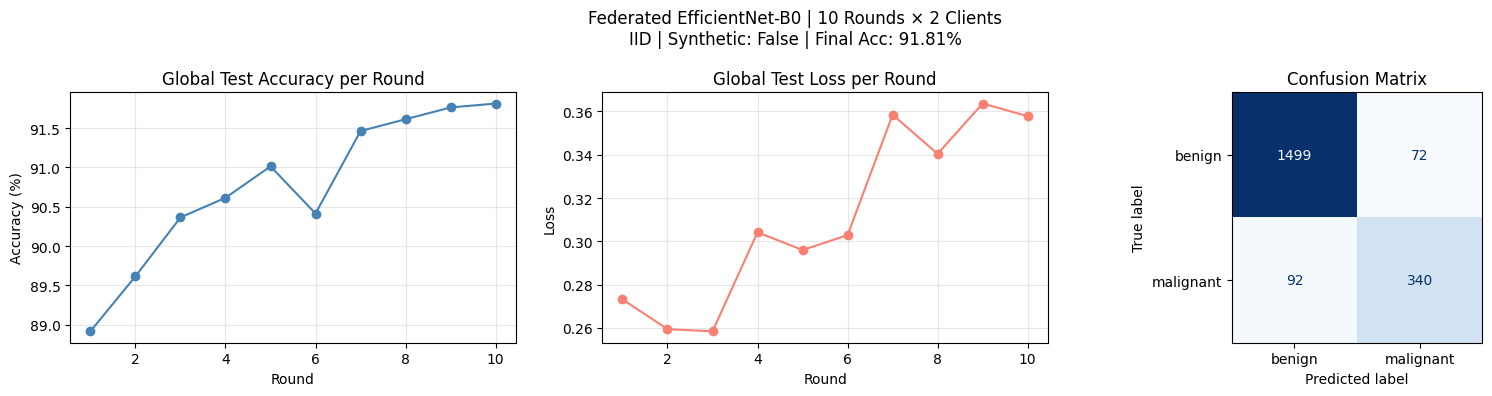

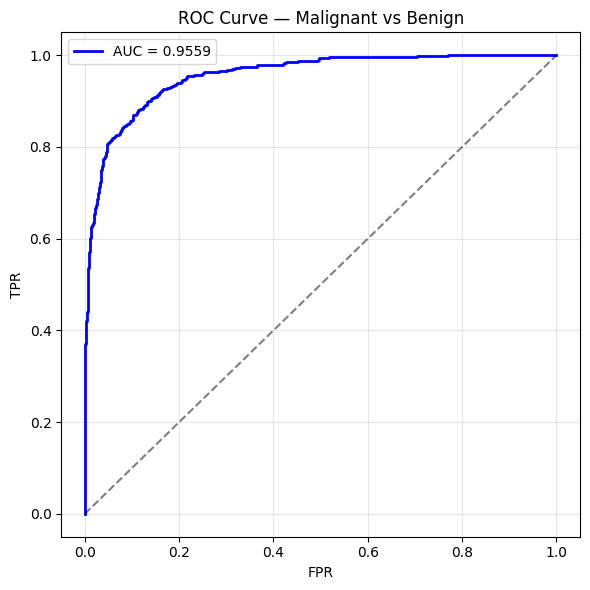

In [ ]:
# ── Final metrics & plots ─────────────────────────────────────────

loss, acc, preds, labels, probs = evaluate_clf(global_clf_model, test_loader)

print(f"\nGlobal Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"Global Test Loss : {loss:.4f}")

try:
    auc = roc_auc_score(labels, probs)
    print(f"AUC-ROC          : {auc:.4f}")
except Exception as e:
    auc  = None
    print(f"AUC skipped: {e}")

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1, len(round_accs)+1), [a*100 for a in round_accs], 'o-', color='steelblue')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Global Test Accuracy per Round'); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(round_losses)+1), round_losses, 'o-', color='salmon')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Loss')
axes[1].set_title('Global Test Loss per Round'); axes[1].grid(alpha=0.3)

cm   = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix')

plt.suptitle(
    f"Federated EfficientNet-B0 | {CLF_NUM_ROUNDS} Rounds × {NUM_CLIENTS} Clients\n"
    f"{'IID' if IID_SPLIT else 'Non-IID'} | "
    f"Synthetic: {SYNTHETIC_AUGMENT} | Final Acc: {acc*100:.2f}%"
)
plt.tight_layout()
plt.savefig(os.path.join(CLF_SAVE_DIR, 'results.png'), dpi=150)
plt.show()

if auc is not None:
    fpr, tpr, _ = roc_curve(labels, probs)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0,1],[0,1],'k--',alpha=0.5)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('ROC Curve — Malignant vs Benign')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [ ]:
# ── Baseline vs Augmented Comparison ─────────────────────────────

BASELINE_PATH = '/content/classifier_round_010.pt'

if os.path.exists(BASELINE_PATH):
    baseline_model = build_classifier()
    baseline_model.load_state_dict(torch.load(BASELINE_PATH, map_location=device))
    loss_b, acc_b, preds_b, labels_b, probs_b = evaluate_clf(baseline_model, test_loader)

    delta = (acc - acc_b) * 100
    symbol = '▲' if delta > 0 else '▼'

    print("=" * 50)
    print(f"  BASELINE   (real data only)     : {acc_b*100:.2f}%")
    print(f"  AUGMENTED  (real + DDIM synth)  : {acc*100:.2f}%")
    print(f"  Delta                           : {symbol} {abs(delta):.2f}%")
    print("=" * 50)

    try:
        auc_b = roc_auc_score(labels_b, probs_b)
        print(f"\n  Baseline  AUC-ROC : {auc_b:.4f}")
        if auc is not None:
            print(f"  Augmented AUC-ROC : {auc:.4f}")
            print(f"  Delta             : {(auc - auc_b):+.4f}")
    except Exception:
        pass
else:
    print(f"Baseline weights not found at {BASELINE_PATH}")

  BASELINE   (real data only)     : 91.66%
  AUGMENTED  (real + DDIM synth)  : 91.81%
  Delta                           : ▲ 0.15%

  Baseline  AUC-ROC : 0.9572
  Augmented AUC-ROC : 0.9559
  Delta             : -0.0013


In [ ]:
# ── FID Score ─────────────────────────────────────────────────────

class InceptionFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        inc = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                                  transform_input=False)
        self.layers = nn.Sequential(
            inc.Conv2d_1a_3x3, inc.Conv2d_2a_3x3, inc.Conv2d_2b_3x3,
            nn.MaxPool2d(3, 2),
            inc.Conv2d_3b_1x1, inc.Conv2d_4a_3x3,
            nn.MaxPool2d(3, 2),
            inc.Mixed_5b, inc.Mixed_5c, inc.Mixed_5d,
            inc.Mixed_6a, inc.Mixed_6b, inc.Mixed_6c, inc.Mixed_6d, inc.Mixed_6e,
            inc.Mixed_7a, inc.Mixed_7b, inc.Mixed_7c,
            nn.AdaptiveAvgPool2d((1, 1)),
        )
    def forward(self, x):
        return self.layers(x).view(x.size(0), -1)

def get_inception_features(loader, extractor, max_samples=2048):
    extractor.eval(); feats = []; n = 0
    with torch.no_grad():
        for images, _ in tqdm(loader, desc='  Features', leave=False):
            if n >= max_samples: break
            feats.append(extractor(images.to(device)).cpu().numpy())
            n += images.size(0)
    return np.concatenate(feats)[:max_samples]

def compute_fid(fr, fg):
    mu_r, sigma_r = fr.mean(0), np.cov(fr, rowvar=False)
    mu_g, sigma_g = fg.mean(0), np.cov(fg, rowvar=False)
    diff           = mu_r - mu_g
    covmean, _     = linalg.sqrtm(sigma_r @ sigma_g, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_r + sigma_g - 2.0 * covmean))

MIN_FID_SAMPLES = 512   # absolute minimum; 2048 is ideal

if os.path.exists(SYN_MALIGNANT_DIR) and len(os.listdir(SYN_MALIGNANT_DIR)) >= MIN_FID_SAMPLES:
    fid_transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    #real malignant only, same class as what was generated
    real_full = datasets.ImageFolder(BASE_DATA_DIR, transform=fid_transform)
    mal_label = real_full.class_to_idx.get('malignant', 1)
    mal_indices = [i for i, (_, lbl) in enumerate(real_full.samples) if lbl == mal_label]
    print(f"[FID] Real malignant images available : {len(mal_indices)}")

    syn_full = datasets.ImageFolder(SYNTHETIC_PATH, transform=fid_transform, allow_empty=True)
    n_syn = len(syn_full)
    print(f"[FID] Synthetic images available      : {n_syn}")

    n_fid = min(len(mal_indices), n_syn, 2048)
    print(f"[FID] Using {n_fid} images per set")

    if n_fid < MIN_FID_SAMPLES:
        print(f"Only {n_fid} images available — FID unreliable. Increase SYNTH_PER_CLASS to ≥ {MIN_FID_SAMPLES}.")
    else:
        extractor  = InceptionFeatureExtractor().to(device)
        fr = get_inception_features(
            DataLoader(Subset(real_full, mal_indices[:n_fid]), batch_size=32, num_workers=2),
            extractor, max_samples=n_fid)
        fg = get_inception_features(
            DataLoader(syn_full, batch_size=32, num_workers=2),
            extractor, max_samples=n_fid)

        fid = compute_fid(fr, fg)
        print(f"\nFID Score (malignant vs malignant): {fid:.1f}")
        print(f"Note: 64×64→299×299 upscaling adds ~50-100 pts to FID regardless of quality.")
        print(f"      Adjusted estimate (subtract resolution penalty): ~{max(0, fid-75):.1f}")

        quality = ('Excellent' if fid < 50 else 'Good' if fid < 100 else
                   'Moderate' if fid < 200 else 'Poor — likely resolution-limited')
        print(f"Quality (raw): {quality}")
else:
    n_available = len(os.listdir(SYN_MALIGNANT_DIR)) if os.path.exists(SYN_MALIGNANT_DIR) else 0
    print(f"[FID] Skipped — only {n_available} synthetic images.")
    print(f"      Need at least {MIN_FID_SAMPLES}. Set SYNTH_PER_CLASS ≥ {MIN_FID_SAMPLES} and re-run Phase 3.")

[FID] Real malignant images available : 1954
[FID] Synthetic images available      : 1500
[FID] Using 1500 images per set
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 179MB/s] 
/tmp/ipykernel_1497/2541181110.py:49: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _     = linalg.sqrtm(sigma_r @ sigma_g, disp=False)



FID Score (malignant vs malignant): 218.0
Note: 64×64→299×299 upscaling adds ~50-100 pts to FID regardless of quality.
      Adjusted estimate (subtract resolution penalty): ~143.0
Quality (raw): Poor — likely resolution-limited
